# Set Environment & Globals


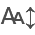

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


In [1]:
%load_ext jupyter_black

# base
import os
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import scanpy as sc
import spatialdata as sd
import spatialdata_plot as sdp
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter

converter = get_converter()
%load_ext rpy2.ipython

In [2]:
# analysis & device specific
%matplotlib inline
CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

# Access SpatialData

In [ ]:
# LOAD
sdata = sd.read_zarr(DATADIR / "processed" / "spatial" / "raws" / "COMBINED_RAW")
samples = list(sdata["square_008um"].obs["Identifier"].unique())

### Import data

In [3]:
samples, sdatas, barcodes = GetSpatialData(
    os.path.join(DATADIR, "spaceranger", "LM13969"),
    os.path.join(DATADIR, "processed", "spatial", "raws"),
    exclude=["LFD-cKO-male-780-VAT-2"],
    overwrite=False,
    get_sdata=True,
)

sdata = sd.concatenate(sdatas, concatenate_tables=True)

0it [00:00, ?it/s]WARNING:ome_zarr.io:version mismatch: detected: RasterFormatV02, requested: FormatV04


LFD-CTR-male-670-VAT


1it [00:25, 25.33s/it]WARNING:ome_zarr.io:version mismatch: detected: RasterFormatV02, requested: FormatV04


HFD-cKO-male-666-VAT


2it [00:45, 22.22s/it]WARNING:ome_zarr.io:version mismatch: detected: RasterFormatV02, requested: FormatV04


LFD-cKO-male-780-VAT


3it [01:04, 21.45s/it]
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/spatialdata/_core/concatenate.py:257: DeprecationWarning: The "tables" argument is deprecated and will be removed in a future version. Please specifies the tables in the `elements` argument. Until the removal occurs, the `elements` variable will be automatically populated with the tables if the `tables` argument is not None.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/spatialdata/_core/concatenate.py:257: DeprecationWarning: The "tables" argument is deprecated and will be removed in a future version. Please specifies the tables in the `elements` argument. Until the removal occurs, the `elements` variable will be automatically populated with the tables if the `tables` argument is not None.
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/spatialdata/_core/concatenate.py:257: DeprecationWarning: The "tables" argument is deprecated and will be removed in

In [ ]:
%%time

# rename to create consistent AnnData .obs names
for csv in barcodes:
    if csv == "JB autocluster.csv":
        newname = "Autocluster Labels"
    elif csv == "JB drawn.csv":
        newname = "ROI Labels"
    elif csv == "EH whole tissue.csv":
        newname = "Whole Tissue"
    else:
        print(csv)

    colname = barcodes[sample][csv].columns[-1]
    barcodes[sample][csv].rename(columns={colname: newname}, inplace=True)

# custom table processing
adatas = []

for samp in samples:
    adata = sdata["square_008um"][sdata["square_008um"].obs["Identifier"] == samp]

    # whole tissue barcodes
    adata.obs["in EH whole tissue"] = adata.obs_names.isin(
        barcodes[samp]["EH whole tissue.csv"].index
    )

    # autocluster barcodes
    adata.obs["in JB autocluster"] = adata.obs_names.isin(
        barcodes[samp]["JB autocluster.csv"].index
    )
    adata.obs = adata.obs.join(barcodes[samp]["JB autocluster.csv"], how="left")
    adata.obs["Autocluster Labels"] = adata.obs["Autocluster Labels"].fillna(
        "not present"
    )
    adata.obs["Autocluster Labels"] = adata.obs["Autocluster Labels"].astype(str)

    # drawn ROIs
    adata.obs["in JB drawn"] = adata.obs_names.isin(
        barcodes[samp]["JB drawn.csv"].index
    )
    adata.obs = adata.obs.join(barcodes[samp]["JB drawn.csv"], how="left")
    adata.obs["ROI Labels"] = adata.obs["ROI Labels"].fillna("not present")
    adata.obs["ROI Labels"] = adata.obs["ROI Labels"].astype(str)

    adatas.append(adata)

adata = sc.concat(adatas)

for col in [
    "in EH whole tissue",
    "in JB autocluster",
    "Autocluster Labels",
    "in JB drawn",
    "ROI Labels",
]:
    sdata["square_008um"].obs[clean_string(col)] = adata.obs[col]

# other metadata
idents = sdata["square_008um"].obs["Identifier"].str.split("-|_", expand=True)
sdata["square_008um"].obs["Diet"] = idents[0]
sdata["square_008um"].obs["Model"] = idents[1]

In [ ]:
%%time
# get aligned hires/lowres images

f, axs = plt.subplots(
    2, len(samples), figsize=(len(samples) * 5, 10), layout="constrained"
)
for i, samp in enumerate(samples):

    # get extents
    adata = sdata["square_008um"]
    data_extent = {}
    mins = np.min(adata[adata.obs["Identifier"] == samp].obsm["spatial"], axis=0)
    maxs = np.max(adata[adata.obs["Identifier"] == samp].obsm["spatial"], axis=0)
    data_extent["x"] = (mins[0], maxs[0])
    data_extent["y"] = (mins[1], maxs[1])

    # hires
    queried_img = bounding_box_query(
        sdata[f"hires_image-{samp}"],
        min_coordinate=[data_extent["x"][0], data_extent["y"][0]],
        max_coordinate=[data_extent["x"][1], data_extent["y"][1]],
        axes=("x", "y"),
        target_coordinate_system=samp,
    )
    sdata[f"queried_hires-{samp}"] = queried_img
    sdata.pl.render_images(f"queried_hires-{samp}").pl.show(
        coordinate_systems=f"{samp}_downscaled_hires", ax=axs[0][i]
    )

    # lowres
    queried_img = bounding_box_query(
        sdata[f"lowres_image-{samp}"],
        min_coordinate=[data_extent["x"][0], data_extent["y"][0]],
        max_coordinate=[data_extent["x"][1], data_extent["y"][1]],
        axes=("x", "y"),
        target_coordinate_system=samp,
    )
    sdata[f"queried_lowres-{samp}"] = queried_img
    sdata.pl.render_images(f"queried_lowres-{samp}").pl.show(
        coordinate_systems=f"{samp}_downscaled_lowres", ax=axs[1][i]
    )

In [ ]:
# SAVE
sdata.write(os.path.join(DATADIR, "processed", "raws", "COMBINED_RAW"))

### Sample Plot

In [ ]:
gene_name = "Adgre1"
trans_cmap = set_zero_in_cmap_to_transparent(cmap="Reds")

f, axs = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
sdata.pl.render_images(
    "rasterized_016um", channel=gene_name, scale="full", cmap=trans_cmap
).pl.show(
    coordinate_systems=sample,
    ax=axs[0],
)

sdata.pl.render_images(f"{sample}_lowres_image", scale="full").pl.show(
    coordinate_systems=sample,
    ax=axs[1],
)

In [ ]:
sdata_small = sdatas[sample].query.bounding_box(
    min_coordinate=[22000, 27000],
    max_coordinate=[25000, 35000],
    axes=("x", "y"),
    target_coordinate_system=sample,
)

gene_name = "Adgre1"
trans_cmap = set_zero_in_cmap_to_transparent(cmap="Reds")

f, axs = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
sdata_small.pl.render_images(
    "rasterized_016um", channel=gene_name, scale="full", cmap=trans_cmap
).pl.show(
    coordinate_systems=sample,
    ax=axs[0],
)

sdata_small.pl.render_images(f"{sample}_lowres_image", scale="full").pl.show(
    coordinate_systems=sample,
    ax=axs[1],
)

# Preprocessing

In [4]:
# LOAD
adata_FULL_WT = sc.read_h5ad(
    os.path.join(DATADIR, "processed", "combined", "raw_processed-V5 WT_filter70.h5ad")
)

### QC

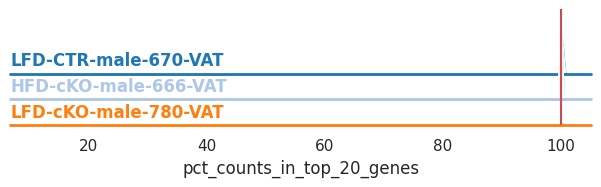

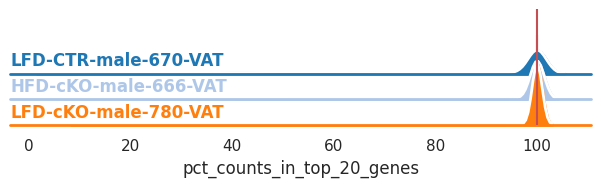

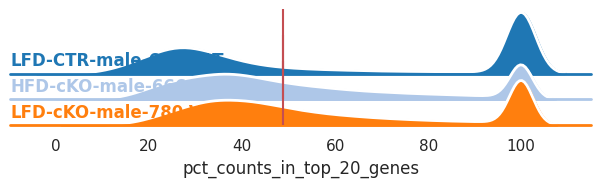

In [18]:
for m, binsize in enumerate(["square_002um", "square_008um", "square_016um"]):
    # calculated QCs
    sc.pp.calculate_qc_metrics(sdata[binsize], inplace=True, percent_top=[20])
    Filter_GeneGroup(sdata[binsize])

    # f, axs = plt.subplots(3, len(samples), figsize=(22, 18), layout="constrained")
    # for n, samp in enumerate(samples):
    #     adata = sdata[binsize][sdata[binsize].obs["Identifier"] == samp]

    #     # Plot QCs
    #     axs[m][n].set_xlim(right=adata.obs["n_genes_by_counts"].quantile(0.05) * 1.1)
    #     sns.histplot(adata.obs["n_genes_by_counts"], ax=axs[m][n], stat="proportion")
    #     plt.axvline(np.mean(adata.obs["n_genes_by_counts"]), color="red")

    # sc.pl.violin(
    #     adata,
    #     ["log1p_n_genes_by_counts", "log1p_total_counts", "pct_counts_mito"],
    #     jitter=0.4,
    #     multi_panel=True,
    # )

    groupby = "Identifier"
    # check_QCPlot(sdata[binsize].obs, "log1p_total_counts", groupby)
    # check_QCPlot(sdata[binsize].obs, "pct_counts_mito", groupby)
    # check_QCPlot(sdata[binsize].obs, "n_genes", groupby)
    check_QCPlot(sdata[binsize].obs, "pct_counts_in_top_20_genes", groupby)

In [ ]:
%%time

# View images
f, axs = plt.subplots(
    1, len(samples), figsize=(len(samples) * 5, 5), layout="constrained"
)
for i, samp in enumerate(samples):
    sdatas[samp].pl.render_images("queried_lowres").pl.show(
        coordinate_systems=samp, ax=axs[i]
    )

In [ ]:
%%time
gene_name = "Igkc"

new_cmap = set_zero_in_cmap_to_transparent(cmap="viridis")

f, axs = plt.subplots(
    1, len(samples), figsize=(len(samples) * 5, 5), layout="constrained"
)
for i, samp in enumerate(samples):
    sdatas[samp].pl.render_shapes(
        f"{samp}_square_008um",
        color=gene_name,
        cmap=new_cmap,
    ).pl.show(coordinate_systems=samp, ax=axs[i])

In [27]:
runFilters = True
adatas = {}


# QC Thresholds
filters = {"GenesPerCell": 60, "ReadsPerCell": 0, "CellsPerGene": 10, "Mito%": 15}

if runFilters is True:
    for s in samples:
        adata = sdata["square_008um"][
            sdata["square_008um"].obs["Identifier"] == s
        ].copy()

        # Filter on whole tissue
        removed = np.sum(adata.obs["in_EH_whole_tissue"] == False)
        print(f"Whole Tissue Filter: {removed} ({removed/adata.shape[0]*100:.2f}%)")
        adata = adata[adata.obs["in_EH_whole_tissue"]]

        # Filter out annoying IgG genes
        adata = adata[:, adata.var_names.str.contains("Igh|Igk|Jchain") == 0]

        # Standard QC Filters
        Filter_QC(
            adata,
            GenePerCell=filters["GenesPerCell"],
            CountPerCell=filters["ReadsPerCell"],
            CellPerGene=filters["CellsPerGene"],
            verbose=True,
        )
        Filter_GeneGroup(
            adata,
            key="mito",
            marker="mt",
            verbose=True,
            perc_threshold=filters["Mito%"],
        )

        print(f"Remaining bins: {adata.shape[0]}\n")
        adatas[s] = adata.copy()

Whole Tissue Filter: 403217 (60.44%)
Cells removed by gene/count filters: 216180 (81.92%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 47707

Whole Tissue Filter: 134857 (23.27%)
Cells removed by gene/count filters: 419511 (94.33%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 25225

Whole Tissue Filter: 192806 (37.13%)
Cells removed by gene/count filters: 321287 (98.42%)
Cells with >15% mito genes: 0 (0.00%)
Remaining bins: 5169



In [ ]:
# plot target genes upon images
new_cmap = set_zero_in_cmap_to_transparent(cmap="viridis")

f, axs = plt.subplots(
    1, len(samples), figsize=(len(samples) * 5, 5), layout="constrained"
)
for i, samp in enumerate(samples):
    sdata.pl.render_images(f"queried_hires-{samp}").pl.render_shapes(
        f"SHAPE_square_008um-{samp}",
        color="Cma1",
        cmap=new_cmap,
    ).pl.show(coordinate_systems=f"{samp}_downscaled_hires", ax=axs[i])

In [28]:
# QC check 2
# adata = sdatas[samp].tables["square_008um"].copy()
for samp in samples:
    adata = adatas[samp].copy()

    # calculated QCs
    sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=[20])
    Filter_GeneGroup(adata)

    # plot QCs
    sc.pl.violin(
        adata,
        ["log1p_n_genes_by_counts", "log1p_total_counts", "pct_counts_mito"],
        jitter=0.4,
        multi_panel=True,
    )

    f, axs = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
    sns.histplot(
        adata.obs["total_counts"],
        kde=True,
        ax=axs[0],
        stat="proportion",
        # log_scale=True,
    )
    axs[0].set_xlim(0, 200)

    sns.histplot(
        adata.obs["n_genes_by_counts"],
        kde=True,
        ax=axs[1],
        stat="proportion",
        # log_scale=True,
    )
    axs[1].set_xlim(0, 200)

In [ ]:
# View unintegrated version

adata_unInt = sdata["square_008um"].copy()
adata_unInt.uns["QC filters"] = filters

# order categories
order_obs(adata_unInt, "Diet", ["LFD", "HFD"])
order_obs(adata_unInt, "Model", ["CTR", "cKO"])

Normalize(adata_unInt, kind="log1p")
FindVariableGenes(
    adata_unInt, kind="seurat_v3", batch_column="Identifier", n_features=100
)

sc.pp.neighbors(adata_unInt)
sc.tl.umap(adata_unInt, key_added=f"UMAP_unintegrated")
lm = LocalMAP()
adata.obsm[f"LocalMAP_unintegrated"] = lm.fit_transform(adata.X.toarray())

plotting = ["Identifier", "log1p_total_counts"]
sc.pl.embedding(adata, "LocalMAP_unintegrated", color=plotting)
sc.pl.embedding(adata, "UMAP_unintegrated", color=plotting)

### Integration

In [31]:
batch_column = "Identifier"
hvg_kind = "seurat_v3"
int_kind = "harmony"

adata_FULL_WT = sc.concat(
    [adatas[samp] for samp in samples],
    join="outer",
)
adata_FULL_WT.uns["QC filters"] = filters
adata_FULL_WT.uns["spatial_attrs"] = sdata["square_008um"].uns["spatial_attrs"]

# order categories
order_obs(adata_FULL_WT, "Diet", ["LFD", "HFD"])
order_obs(adata_FULL_WT, "Model", ["CTR", "cKO"])

Normalize(adata_FULL_WT, kind="log1p")
FindVariableGenes(
    adata_FULL_WT, kind=hvg_kind, batch_column=batch_column, n_features=500
)
print(adata_FULL_WT.var_names[adata_FULL_WT.var["highly_variable"]].to_list(), "\n")

Integrate(adata_FULL_WT, kind=int_kind, batch_column=batch_column, use_var_genes=False)
Visualize(adata_FULL_WT)

Saving normalized counts in layer 'normalized'.
Finding HVGs...
['AU021092', 'Acap1', 'Acer2', 'Acod1', 'Adam8', 'Adamts15', 'Adamts9', 'Adamtsl3', 'Adgrg2', 'Adgrl1', 'Adrb3', 'Ahsa2', 'Alox15', 'Alox5', 'Alpl', 'Angptl8', 'Ankrd10', 'Ankrd6', 'Anks6', 'Anxa9', 'Apol7c', 'Aqp1', 'Arg1', 'Arl2', 'Armc6', 'Arrdc3', 'Avpi1', 'Bbs5', 'Best1', 'Bfsp2', 'Bid', 'Bmp1', 'Brwd3', 'Bub3', 'C1qtnf6', 'Cables1', 'Cacnb3', 'Cadm4', 'Capn3', 'Castor1', 'Catsperb', 'Ccl19', 'Ccl2', 'Ccl21a', 'Ccl22', 'Ccl5', 'Ccl9', 'Ccn1', 'Cct6b', 'Cd163', 'Cd19', 'Cd209f', 'Cd209g', 'Cd37', 'Cd52', 'Cd5l', 'Cd7', 'Cd74', 'Cd79a', 'Cd79b', 'Cd8b1', 'Cdca3', 'Cdk5rap3', 'Cdkn2a', 'Ceacam16', 'Cenpi', 'Cenpq', 'Cep126', 'Chga', 'Clca3a2', 'Cldn1', 'Cldn5', 'Clec9a', 'Clu', 'Cma1', 'Cmah', 'Cnr1', 'Coch', 'Coro1a', 'Cpa3', 'Cr2', 'Crtam', 'Cst6', 'Ctsk', 'Ctsl', 'Ctss', 'Cxcl13', 'Cxcl14', 'Cxcl2', 'Cxcr3', 'Cxcr4', 'Cybb', 'Dcp2', 'Dcps', 'Depdc5', 'Depdc7', 'Deptor', 'Derl3', 'Dgka', 'Dhdds', 'Disp1', 'Dkk2', 'Dkkl

2025-08-19 13:40:05,770 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2025-08-19 13:40:29,971 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2025-08-19 13:40:30,532 - harmonypy - INFO - Iteration 1 of 50
INFO:harmonypy:Iteration 1 of 50
2025-08-19 13:41:11,847 - harmonypy - INFO - Iteration 2 of 50
INFO:harmonypy:Iteration 2 of 50
2025-08-19 13:41:50,542 - harmonypy - INFO - Iteration 3 of 50
INFO:harmonypy:Iteration 3 of 50
2025-08-19 13:42:28,179 - harmonypy - INFO - Iteration 4 of 50
INFO:harmonypy:Iteration 4 of 50
2025-08-19 13:42:46,845 - harmonypy - INFO - Iteration 5 of 50
INFO:harmonypy:Iteration 5 of 50
2025-08-19 13:42:59,282 - harmonypy - INFO - Converged after 5 iterations
INFO:harmonypy:Converged after 5 iterations


Starting UMAP...
Starting LocalMAP...


AnnData object with n_obs × n_vars = 78101 × 12965
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'Identifier', 'in_EH_whole_tissue', 'in_JB_autocluster', 'Autocluster_Labels', 'in_JB_drawn', 'ROI_Labels', 'Diet', 'Model', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'QC filters', 'methods', 'log1p', 'hvg', 'pca', 'neighbors', 'UMAP'
    obsm: 'spatial', 'X_pca', 'integrated', 'UMAP', 'LocalMAP'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'distances', 'connectivities'

In [ ]:
# SAVE
adata_FULL_WT.write(
    os.path.join(
        DATADIR, "processed", "spatial", "combined", "raw_processed-V2.2 WT_filter60.h5ad"
    )
)

# Segmented inputs

In [22]:
print(sdatas[samples[0]]["square_002um"].uns["spatialdata_attrs"])
sdatas[samples[0]]["square_002um"].obs

{'instance_key': 'location_id', 'region': ['SHAPE_square_002um'], 'region_key': 'region'}


Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


In [ ]:
print(adatas[0].uns["spatialdata_attrs"])
adatas[0].obs

{'region': 'cell_segmentation', 'region_key': 'region', 'instance_key': 'location_id'}


Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


In [39]:
from pathlib import Path
from PIL import Image
import spatialdata_io
from spatialdata_io._constants._constants import VisiumHDKeys
from spatialdata.models import TableModel
import json


def read_visium_hd_segmented(
    outs_path: str, sample_id: str, shapes_name: str = "cell_segmentation"
) -> TableModel:
    outs_path = Path(outs_path)
    bin_size = "segmented_outputs"
    path_bin = outs_path / bin_size
    path_bin_spatial = path_bin / VisiumHDKeys.SPATIAL

    # Load gene expression
    counts_file = "raw_feature_cell_matrix.h5"
    adata = sc.read_10x_h5(path_bin / counts_file, gex_only=False)
    adata.var_names_make_unique()

    # Load scalefactors and images
    with open(path_bin_spatial / VisiumHDKeys.SCALEFACTORS_FILE) as f:
        scalefactors = json.load(f)

    hires_img = np.array(Image.open(path_bin_spatial / "tissue_hires_image.png"))
    lowres_img = np.array(Image.open(path_bin_spatial / "tissue_lowres_image.png"))

    library_id = "visium_hd_segmentation"
    adata.uns["spatial"] = {
        library_id: {
            "images": {
                "hires": hires_img,
                "lowres": lowres_img,
            },
            "scalefactors": scalefactors,
            "metadata": {"source_image_path": "tissue_hires_image.png"},
        }
    }

    # Assign region info
    adata.obs[VisiumHDKeys.INSTANCE_KEY] = np.arange(len(adata))
    adata.obs[VisiumHDKeys.REGION_KEY] = shapes_name
    adata.obs[VisiumHDKeys.REGION_KEY] = adata.obs[VisiumHDKeys.REGION_KEY].astype(
        "category"
    )

    # Load cell shapes
    shapes = spatialdata_io.geojson(
        outs_path / "segmented_outputs" / "cell_segmentations.geojson",
        coordinate_system=sample_id,
    )

    # Match shape order to adata
    centroids = shapes.geometry.centroid
    adata.obsm["spatial"] = np.vstack([centroids.x.values, centroids.y.values]).T

    # Estimate spot diameter
    areas = shapes.geometry.area
    mean_area = np.mean(areas)
    diameter_pixels = 2 * np.sqrt(mean_area / np.pi)
    adata.uns["spatial"][library_id]["scalefactors"][
        "spot_diameter_fullres"
    ] = diameter_pixels

    return TableModel.parse(
        adata=adata,
        region=shapes_name,
        region_key=str(VisiumHDKeys.REGION_KEY),
        instance_key=str(VisiumHDKeys.INSTANCE_KEY),
    )


adatas = [
    read_visium_hd_segmented(
        DATADIR / "spaceranger" / "LM13969" / sample / "outs", sample_id=sample
    )
    for sample in samples
]

In [76]:
for sample in samples:
    sdatas[sample]["nucleus_segmentation"] = spatialdata_io.geojson(
        DATADIR
        / "spaceranger"
        / "LM13969"
        / sample
        / "outs"
        / "segmented_outputs"
        / "nucleus_segmentations.geojson",
        coordinate_system=sample,
    )
    # sdatas[sample]["nucleus_segmentation"].reset_index(inplace=True)
    sdatas[sample]["nucleus_segmentation"].rename_axis("location_id", inplace=True)

    sdatas[sample]["cell_segmentation"] = spatialdata_io.geojson(
        DATADIR
        / "spaceranger"
        / "LM13969"
        / sample
        / "outs"
        / "segmented_outputs"
        / "cell_segmentations.geojson",
        coordinate_system=sample,
    )
    # sdatas[sample]["cell_segmentation"].reset_index(inplace=True)
    sdatas[sample]["cell_segmentation"].rename_axis("location_id", inplace=True)

    sdatas[sample][f"segmented_bins"] = read_visium_hd_segmented(
        DATADIR / "spaceranger" / "LM13969" / sample / "outs",
        sample_id=sample,
        shapes_name="cell_segmentation",
    )

INFO     Rasterizing image for faster rendering.                                                                   


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


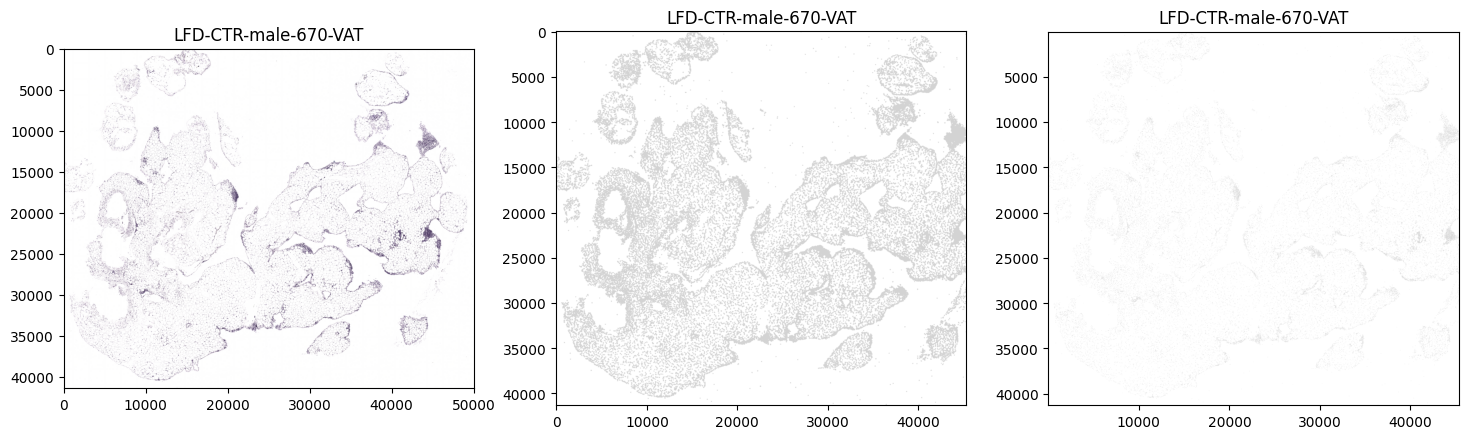

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sdatas[samples[0]].pl.render_images("hires_image").pl.show(
    coordinate_systems=samples[0], ax=axs[0]
)
sdatas[samples[0]].pl.render_shapes("cell_segmentation").pl.show(
    coordinate_systems=samples[0], ax=axs[1]
)
sdatas[samples[0]].pl.render_shapes("nucleus_segmentation").pl.show(
    coordinate_systems=samples[0], ax=axs[2]
)

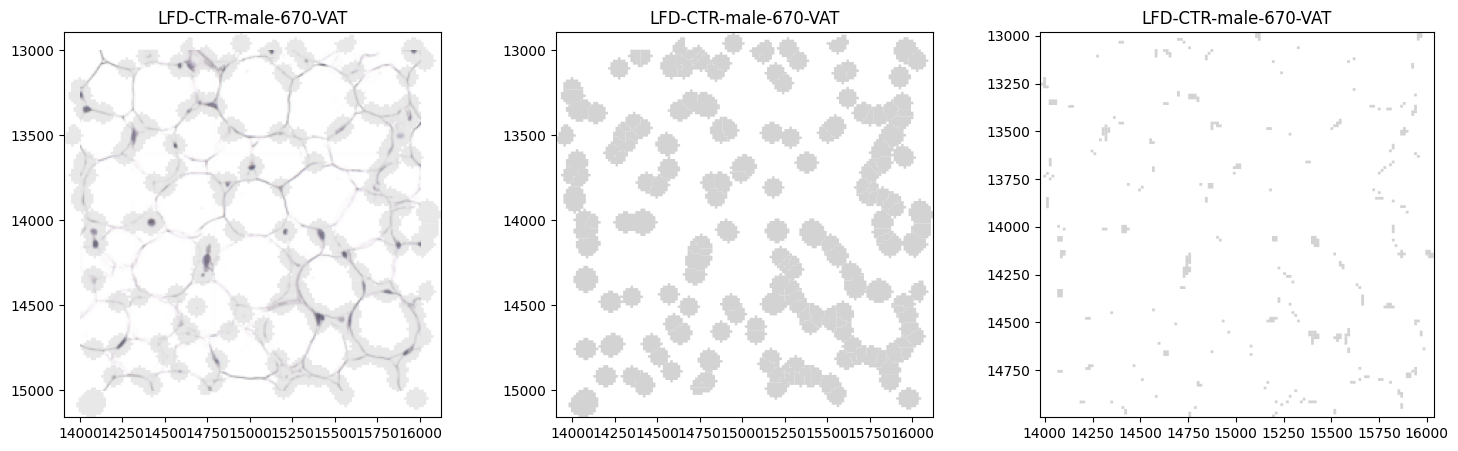

In [84]:
crop_sdata1 = sd.bounding_box_query(
    sdatas[samples[0]],
    axes=("y", "x"),
    min_coordinate=[13000, 14000],
    max_coordinate=[15000, 16000],
    target_coordinate_system=samples[0],
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
crop_sdata1.pl.render_images("hires_image").pl.render_shapes(
    "cell_segmentation", fill_alpha=0.5
).pl.show(coordinate_systems=samples[0], ax=axs[0])
crop_sdata1.pl.render_shapes("cell_segmentation").pl.show(
    coordinate_systems=samples[0], ax=axs[1]
)
crop_sdata1.pl.render_shapes("nucleus_segmentation").pl.show(
    coordinate_systems=samples[0], ax=axs[2]
)

In [ ]:
sc.pp.calculate_qc_metrics(crop_sdata1["segmented_bins"], inplace=True)

In [55]:
crop_sdata1["segmented_bins"].var.sort_values("n_cells_by_counts", ascending=False)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


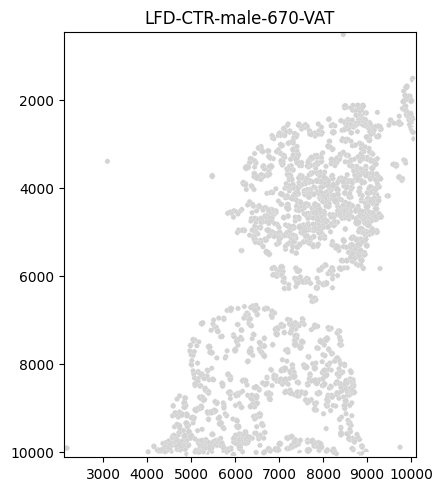

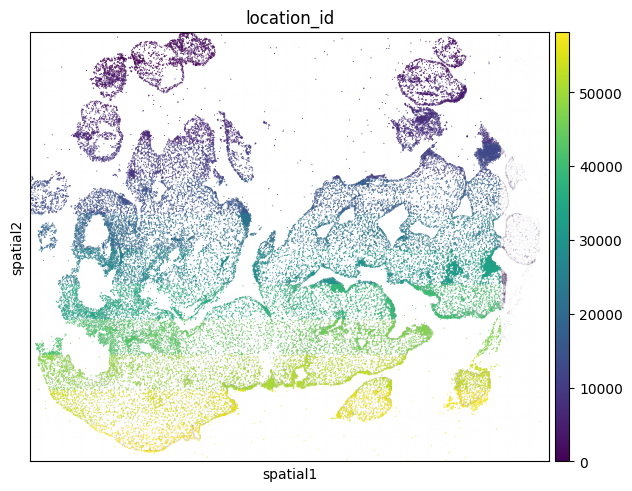

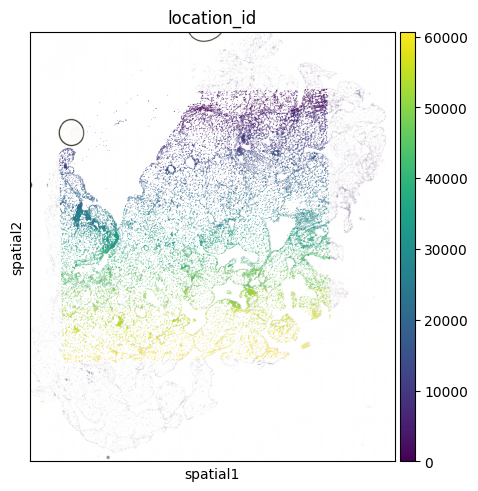

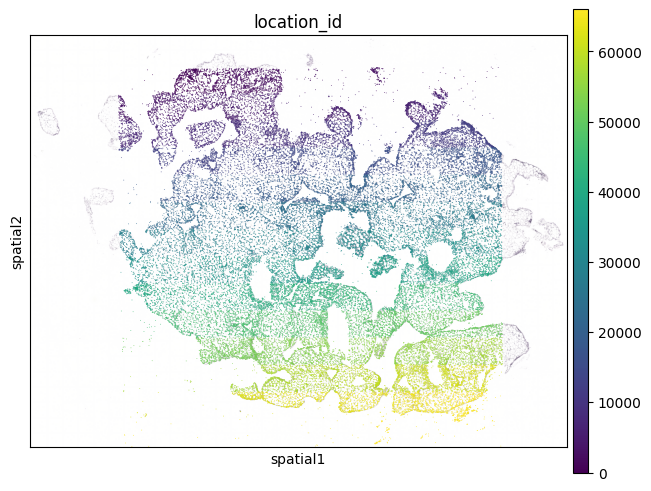

In [18]:
import squidpy as sq

for n, ad in enumerate(adatas):
    sq.pl.spatial_scatter(ad, shape="circle", color="location_id")
    ad.obs["Identifier"] = samples[n]

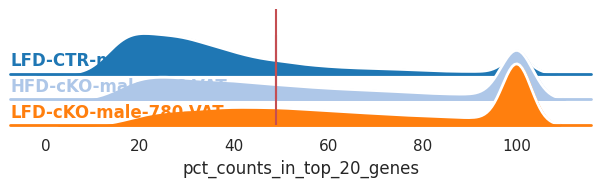

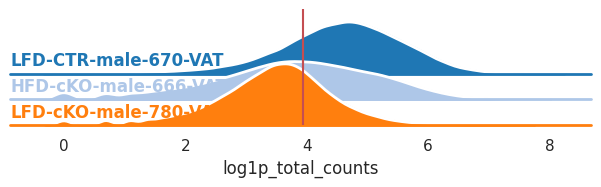

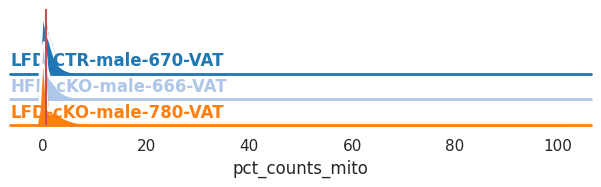

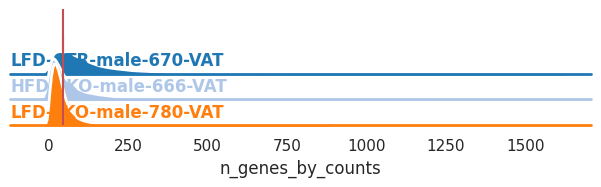

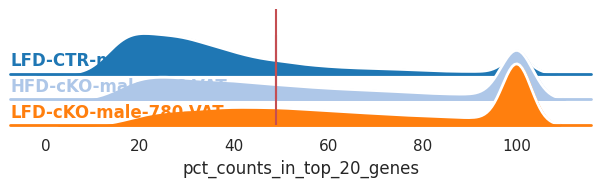

In [ ]:
# calculated QCs
for ad in adatas:
    sc.pp.calculate_qc_metrics(ad, inplace=True, percent_top=[20])
    Filter_GeneGroup(ad)

metadata = pd.concat([i.obs for i in adatas])
groupby = "Identifier"
check_QCPlot(metadata, "log1p_total_counts", groupby)
check_QCPlot(metadata, "pct_counts_mito", groupby)
check_QCPlot(metadata, "n_genes_by_counts", groupby)
check_QCPlot(metadata, "pct_counts_in_top_20_genes", groupby)

metadata

Cells removed by gene/count filters: 8456 (14.52%)
Cells with >15% mito genes: 17 (0.03%)
Remaining bins: 49783

Cells removed by gene/count filters: 24898 (41.01%)
Cells with >15% mito genes: 7 (0.02%)
Remaining bins: 35810

Cells removed by gene/count filters: 33373 (50.58%)
Cells with >15% mito genes: 11 (0.03%)
Remaining bins: 32612



AnnData object with n_obs × n_vars = 118205 × 8391
    obs: 'location_id', 'region', 'Identifier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito', 'n_genes', 'n_counts'
    obsm: 'spatial'

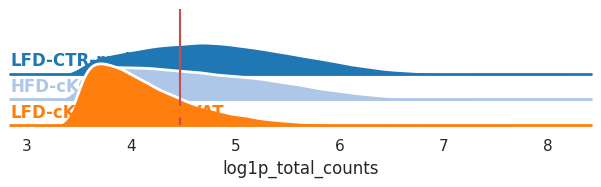

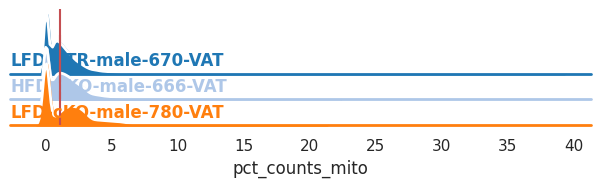

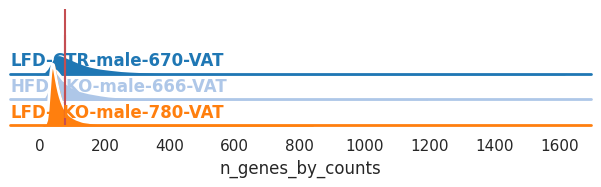

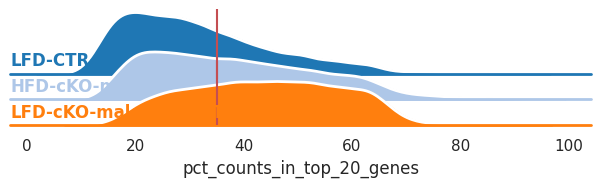

In [35]:
runFilters = True
processed = []

# QC Thresholds
filters = {"GenesPerCell": 32, "ReadsPerCell": 0, "CellsPerGene": 50, "Mito%": 15}

for n, ad in enumerate(adatas):
    adata = ad.copy()

    # # Filter on whole tissue
    # removed = np.sum(adata.obs["in_EH_whole_tissue"] == False)
    # print(f"Whole Tissue Filter: {removed} ({removed/adata.shape[0]*100:.2f}%)")
    # adata = adata[adata.obs["in_EH_whole_tissue"]]

    # # Filter out annoying IgG genes
    # adata = adata[:, adata.var_names.str.contains("Igh|Igk|Jchain") == 0]

    # Standard QC Filters
    Filter_QC(
        adata,
        GenePerCell=filters["GenesPerCell"],
        CountPerCell=filters["ReadsPerCell"],
        CellPerGene=filters["CellsPerGene"],
        verbose=True,
    )
    Filter_GeneGroup(
        adata,
        key="mito",
        marker="mt",
        verbose=True,
        perc_threshold=filters["Mito%"],
    )

    print(f"Remaining bins: {adata.shape[0]}\n")
    adata.obs["Identifier"] = samples[n]

    processed.append(adata)

adata_FULL = sc.concat(processed)

groupby = "Identifier"
check_QCPlot(adata_FULL.obs, "log1p_total_counts", groupby)
check_QCPlot(adata_FULL.obs, "pct_counts_mito", groupby)
check_QCPlot(adata_FULL.obs, "n_genes_by_counts", groupby)
check_QCPlot(adata_FULL.obs, "pct_counts_in_top_20_genes", groupby)
adata_FULL

In [37]:
# clean mitochondrial genes
adata_FULL.var["mito"] = adata_FULL.var_names.str.startswith("mt-")
adata_FULL.obsm["MT"] = adata_FULL[:, adata_FULL.var["mito"].values].X.toarray()
adata_FULL = adata_FULL[:, ~adata_FULL.var["mito"].values]

Get reference dataset

In [ ]:
batch_column = "Identifier"
adata_FULL.layers["counts"] = adata_FULL.X.copy()
Normalize(adata_FULL)
FindVariableGenes(adata_FULL, "seurat_v3", batch_column, 50)
Integrate(adata_FULL, batch_column)

In [ ]:
sdata

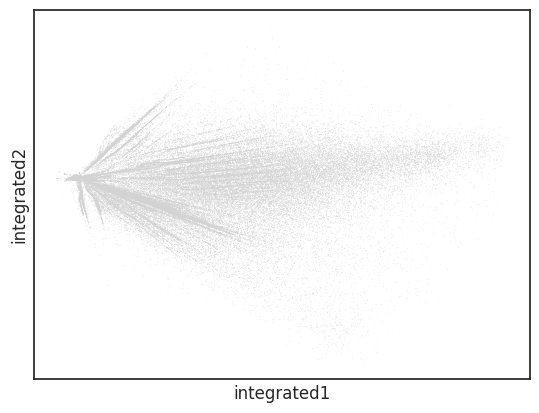

In [42]:
def Visualize(
    adata: AnnData,
    key: str = "",
    use_rep: str = "integrated",
    neighbor_key: str = None,
    LocalMAP=True,
):
    print("Starting UMAP...")
    sc.pp.neighbors(adata, use_rep=use_rep, key_added=neighbor_key)
    sc.tl.umap(adata, key_added=f"UMAP{key}", neighbors_key=neighbor_key)

    # LocalMAP
    if LocalMAP is True:
        print("Starting LocalMAP...")
        lm = LocalMAP()
        if use_rep == "integrated":
            adata.obsm[f"LocalMAP{key}"] = lm.fit_transform(adata.obsm[use_rep])
        elif use_rep is not None:
            adata.obsm[f"LocalMAP{key}"] = lm.fit_transform(adata.layers[use_rep])
        else:
            adata.obsm[f"LocalMAP{key}"] = lm.fit_transform(adata.X)

    return adata


# Visualize(adata_FULL, LocalMAP=False)
sc.pl.embedding(adata_FULL, "integrated")

In [28]:
Cluster(adata_FULL, resolutions=[0.5, 0.8, 1.0, 1.2, 1.5])

100%|██████████| 5/5 [16:44<00:00, 200.86s/it]


AnnData object with n_obs × n_vars = 118205 × 8378
    obs: 'location_id', 'region', 'Identifier', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mito', 'n_genes', 'n_counts', 'leiden_0.5', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.5'
    var: 'mito', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'methods', 'log1p', 'hvg', 'pca', 'neighbors', 'UMAP', 'leiden_0.5', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.5'
    obsm: 'spatial', 'MT', 'X_pca', 'integrated', 'UMAP', 'LocalMAP'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'distances', 'connectivities'

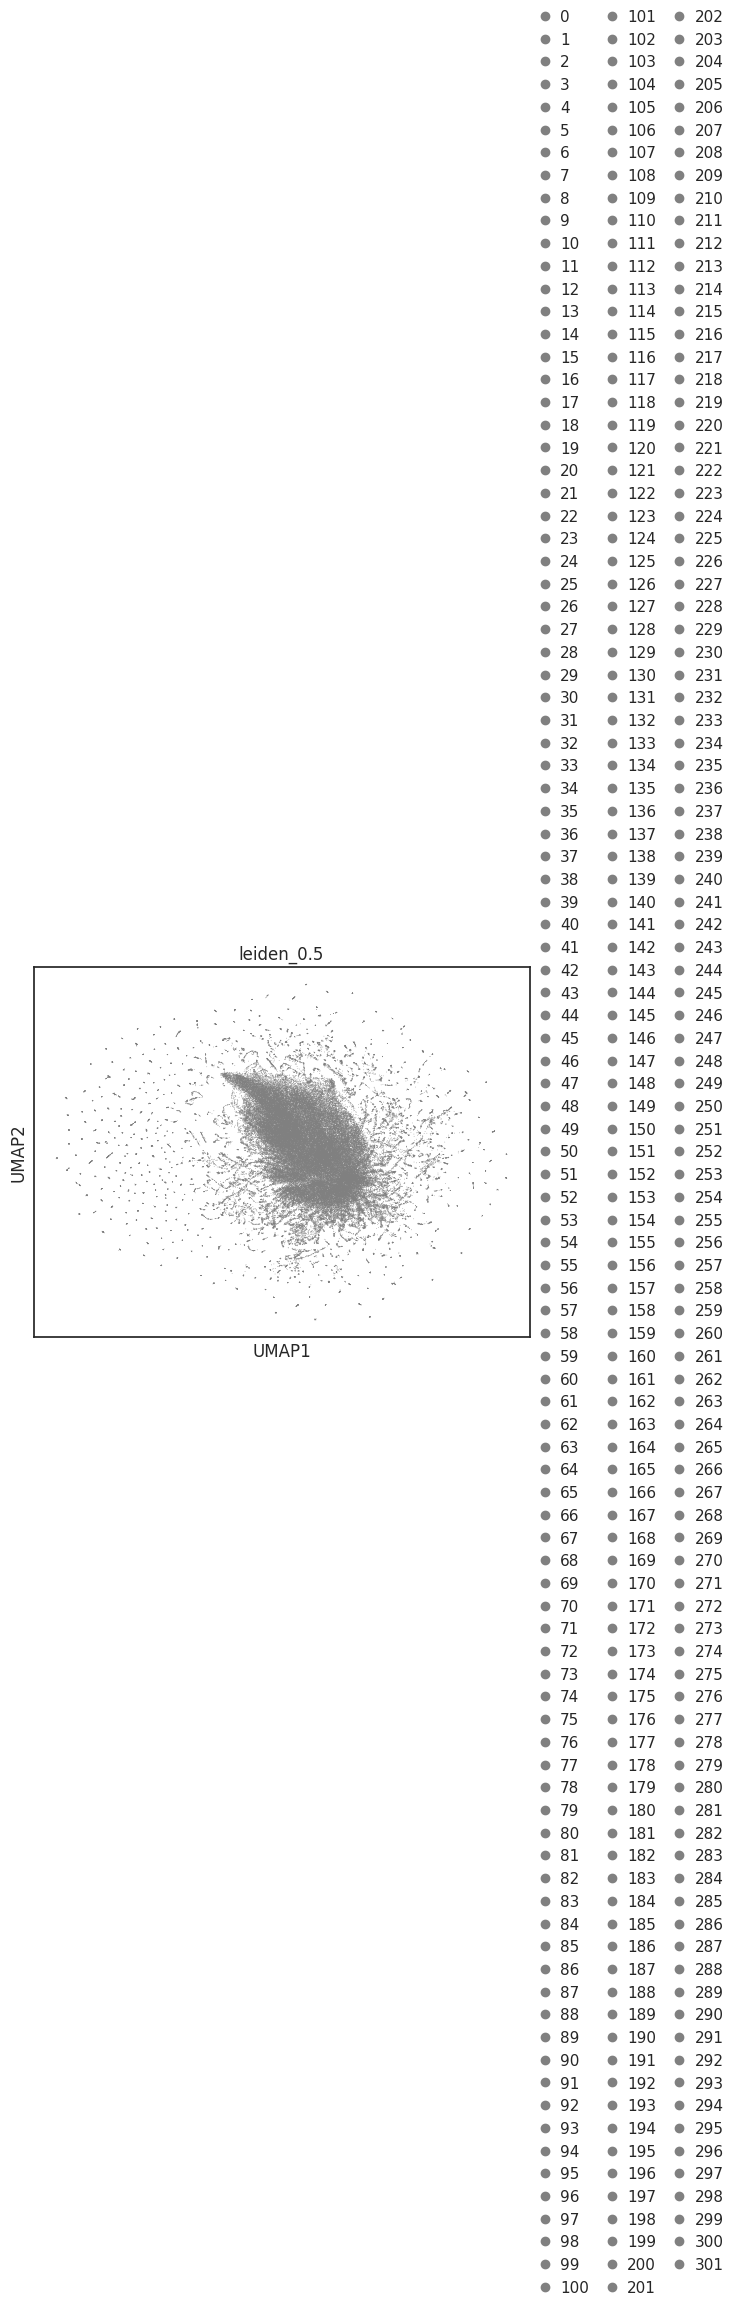

In [33]:
sc.pl.embedding(adata_FULL, "UMAP", color="leiden_0.5")
# sq.pl.spatial_scatter(ad, shape="circle", color="location_id")